# Simulación del movimiento browniano

Integramos numéricamente la **ecuación de Langevin completa** (con inercia) usando el **método de Euler** junto con el **incremento de Wiener**.

La ecuación de Langevin dice que la masa por la aceleración es igual a la fuerza de fricción (proporcional y opuesta a la velocidad) más una fuerza estocástica producida por los choques con las moléculas del fluido:

$$m\,\frac{d\mathbf{V}}{dt} = -\zeta\,\mathbf{V} + \mathbf{F}_{\text{estocástica}}$$

donde $m$ es la masa, $\zeta$ el coeficiente de fricción y $\mathbf{F}_{\text{estocástica}}$ el ruido.

## Discretización por el método de Euler

**Velocidad.** La nueva velocidad es la anterior amortiguada por la fricción, más el impulso aleatorio acumulado dividido por la masa:

$$\mathbf{V}_{i+1} = \left(1 - \frac{\zeta}{m}\,\Delta t\right)\mathbf{V}_i + \frac{1}{m}\,\Delta\mathbf{W}_i$$

**Posición.** La nueva posición es la anterior más la velocidad por el paso de tiempo:

$$\mathbf{R}_{i+1} = \mathbf{R}_i + \mathbf{V}_i\,\Delta t$$

El impulso aleatorio $\Delta\mathbf{W}_i$ (incremento de Wiener) tiene media cero, y su correlación fija la intensidad del ruido en función de la temperatura:

$$\langle \Delta\mathbf{W}_i \rangle = 0, \qquad \langle \Delta W_i\,\Delta W_j \rangle = 2\,k_B T\,\zeta\,\Delta t\;\delta_{ij}$$

Por eso el impulso se genera como un número gaussiano de desviación estándar $\sqrt{2\,k_B T\,\zeta\,\Delta t}$.

## 1. Módulos

In [1]:
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt

## 2. Parámetros físicos y numéricos

In [2]:
dimension              = 3       # sistema tridimensional
numero_particulas      = 500     # partículas brownianas independientes
numero_pasos           = 10000    # pasos de la simulación
paso_tiempo            = 0.05    # incremento finito en el tiempo (Delta t)
coeficiente_friccion   = 1.0     # constante de fricción (zeta = masa * gamma)
masa_particula         = 1.0     # masa de cada partícula
temperatura            = 1.0     # temperatura por k_B (es decir, k_B * T)

# Desviación estándar del impulso aleatorio (incremento de Wiener):
# desviacion_impulso = np.sqrt(2 * kB*T * friccion * paso_tiempo)
desviacion_impulso = np.sqrt(2 * temperatura * coeficiente_friccion * paso_tiempo)

np.random.seed(0)   # semilla para reproducibilidad

## 3. Arreglos de estado e historia

Guardamos el **estado actual** de cada partícula (posición, velocidad e impulso) y la **historia completa** de la simulación, con un "fotograma" por paso de tiempo.

In [3]:
# Estado actual de cada partícula (una fila por partícula, una columna por eje)
posicion = np.zeros([numero_particulas, dimension])           # posición actual
velocidad = np.zeros([numero_particulas, dimension])          # velocidad actual
impulso_aleatorio = np.zeros([numero_particulas, dimension])  # impulso actual

# Contenedores para almacenar la historia completa de la simulación
historia_posicion = np.zeros([numero_pasos, numero_particulas, dimension])
historia_velocidad = np.zeros([numero_pasos, numero_particulas, dimension])
historia_impulso = np.zeros([numero_pasos, numero_particulas, dimension])
historia_tiempo = np.zeros([numero_pasos])

## 4. Función de un paso de integración

`avanzar_un_paso` aplica las dos fórmulas de Euler de la introducción a **todas las partículas a la vez** (operaciones vectorizadas de NumPy).

In [4]:
def avanzar_un_paso(posicion, velocidad, desviacion_impulso,
                    coeficiente_friccion, masa_particula, paso_tiempo):
    """Avanza un paso de tiempo (método de Euler) la ecuación de Langevin.

    Devuelve (posicion_nueva, velocidad_nueva, impulso_aleatorio).
    """
    # Impulso aleatorio: un vector gaussiano por partícula (incremento de Wiener)
    impulso_aleatorio = desviacion_impulso * np.random.randn(
        numero_particulas, dimension)

    # Nueva posición = posición + velocidad * paso_tiempo
    posicion_nueva = posicion + velocidad * paso_tiempo

    # Nueva velocidad = (1 - (friccion/masa)*paso_tiempo) * velocidad
    #                   + impulso_aleatorio / masa
    factor_friccion = 1.0 - coeficiente_friccion / masa_particula * paso_tiempo
    velocidad_nueva = factor_friccion * velocidad + impulso_aleatorio / masa_particula

    return posicion_nueva, velocidad_nueva, impulso_aleatorio

## 5. Bucle de simulación

En cada paso avanzamos todas las partículas y guardamos su estado en los arreglos de historia.

In [5]:
for indice_paso in range(numero_pasos):
    posicion, velocidad, impulso_aleatorio = avanzar_un_paso(
        posicion, velocidad, desviacion_impulso,
        coeficiente_friccion, masa_particula, paso_tiempo)

    historia_posicion[indice_paso] = posicion
    historia_velocidad[indice_paso] = velocidad
    historia_impulso[indice_paso] = impulso_aleatorio
    historia_tiempo[indice_paso] = indice_paso * paso_tiempo   # tiempo = i * paso_tiempo

print(f"Simulación lista: {numero_particulas} partículas, {numero_pasos} pasos.")

Simulación lista: 500 partículas, 10000 pasos.


## 6. Animación 3D con Plotly

Cada cuadro muestra la **nube de partículas** (puntos) y la **trayectoria** de una partícula destacada (línea). Usa el botón ▶ Play o el deslizador para recorrer el tiempo, y arrastra con el mouse para rotar.

El **color** de las partículas se elige descomentando una de las tres opciones dentro de `nube_de_particulas`.

In [ ]:
tamano_caja = 40            # tamaño de la caja de visualización
intervalo_muestreo = 16     # 1 de cada N pasos (menos frames = más liviano)
particula_destacada = 0     # índice de la partícula cuya trayectoria se dibuja

# --- Color de las partículas ---
# OPCIÓN 1: un solo color fijo para todas (nombre o código hex)
color_particulas = 'mediumpurple'

# OPCIÓN 2: cada partícula con su propio color (uno por partícula)
paleta = ['red', 'blue', 'green', 'orange', 'purple', 'teal',
          'magenta', 'gold', 'cyan', 'crimson']
colores_por_particula = [paleta[i % len(paleta)]
                         for i in range(numero_particulas)]

indices_animados = list(range(0, numero_pasos, intervalo_muestreo))

def nube_de_particulas(indice_paso):
    """Marcadores: todas las partículas en el paso indicado."""
    # OPCIÓN 1: un color fijo para todas
    # marcador = dict(size=4, color=color_particulas, opacity=0.6)

    # OPCIÓN 2: cada partícula con su color (descomenta para usar)
    # marcador = dict(size=4, color=colores_por_particula, opacity=0.6)

    # OPCIÓN 3: color según la rapidez = np.sqrt(vx^2 + vy^2 + vz^2)
    rapidez = np.sqrt(np.sum(historia_velocidad[indice_paso]**2, axis=1))
    marcador = dict(size=4, color=rapidez, opacity=0.6,
                    colorscale='Viridis', showscale=True,
                    colorbar=dict(title='rapidez', x=1.0))

    return go.Scatter3d(
        x=historia_posicion[indice_paso, :, 0],
        y=historia_posicion[indice_paso, :, 1],
        z=historia_posicion[indice_paso, :, 2],
        mode='markers', marker=marcador, name='partículas')

def trayectoria_destacada(indice_paso):
    """Línea azul: camino de la partícula destacada hasta el paso indicado."""
    indice_final = max(indice_paso, 1)
    return go.Scatter3d(
        x=historia_posicion[:indice_final, particula_destacada, 0],
        y=historia_posicion[:indice_final, particula_destacada, 1],
        z=historia_posicion[:indice_final, particula_destacada, 2],
        mode='lines', line=dict(color='blue', width=3), name='trayectoria')

lista_frames = [
    go.Frame(data=[nube_de_particulas(i), trayectoria_destacada(i)], name=str(i))
    for i in indices_animados]

figura_animacion = go.Figure(
    data=[nube_de_particulas(indices_animados[0]),
          trayectoria_destacada(indices_animados[0])],
    frames=lista_frames)

rango_ejes = dict(range=[-tamano_caja / 2, tamano_caja / 2])
figura_animacion.update_layout(
    # Título arriba del todo, centrado, separado de la gráfica
    title=dict(text='Movimiento browniano (ecuación de Langevin)',
               y=0.97, x=0.5, xanchor='center', yanchor='top'),
    scene=dict(xaxis=dict(title='x', **rango_ejes),
               yaxis=dict(title='y', **rango_ejes),
               zaxis=dict(title='z', **rango_ejes)),
    width=750, height=700,
    margin=dict(t=60, b=40),   # margen superior e inferior para que respire
    # Leyenda horizontal, debajo de la gráfica (ya no choca con el título)
    legend=dict(orientation='h', yanchor='bottom', y=-0.08,
                xanchor='center', x=0.5),
    updatemenus=[dict(
        type='buttons', showactive=False,
        buttons=[
            dict(label='▶ Play', method='animate',
                 args=[None, dict(frame=dict(duration=40, redraw=True),
                                  fromcurrent=True)]),
            dict(label='❚❚ Pause', method='animate',
                 args=[[None], dict(frame=dict(duration=0, redraw=False),
                                    mode='immediate')])
        ])],
    sliders=[dict(
        active=0, x=0.1, len=0.85, currentvalue=dict(prefix='t = '),
        steps=[dict(method='animate', label=f'{historia_tiempo[i]:.1f}',
                    args=[[str(i)], dict(mode='immediate',
                                         frame=dict(duration=0, redraw=True))])
               for i in indices_animados])]
)

figura_animacion.show()

## 7. Verificación física: desplazamiento cuadrático medio

El **desplazamiento cuadrático medio** (MSD) es el promedio sobre partículas del cuadrado de la distancia al origen. A tiempos largos ($t \gg m/\zeta$) el movimiento es difusivo y crece linealmente con el tiempo:

$$\langle R^2 \rangle = 6\,D\,t \qquad \text{(en 3 dimensiones)}$$

donde el coeficiente de difusión sale de la **relación de Einstein**:

$$D = \frac{k_B T}{\zeta}$$

Comparar la curva simulada con la recta $6Dt$ confirma que la simulación reproduce la física esperada.

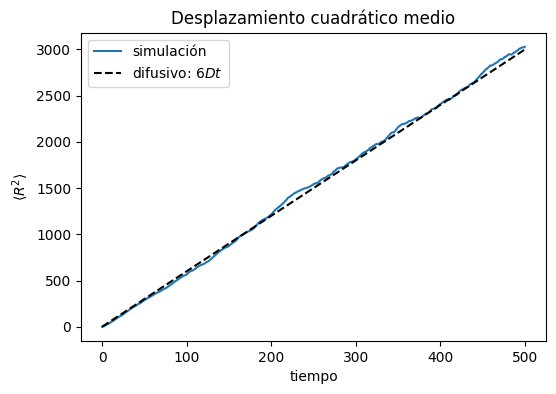

In [7]:
coeficiente_difusion = temperatura / coeficiente_friccion   # relación de Einstein

# Promedio sobre partículas de |posicion|^2
desplazamiento_cuadratico_medio = np.mean(
    np.sum(historia_posicion**2, axis=2), axis=1)

plt.figure(figsize=(6, 4))
plt.plot(historia_tiempo, desplazamiento_cuadratico_medio, label='simulación')
plt.plot(historia_tiempo, 6 * coeficiente_difusion * historia_tiempo,
         'k--', label=r'difusivo: $6Dt$')
plt.xlabel('tiempo'); plt.ylabel(r'$\langle R^2 \rangle$')
plt.legend(); plt.title('Desplazamiento cuadrático medio')
plt.show()